# ENGR 140 -- Depreciation, Taxation, Replacement, and Benefit-Cost Analysis

Four tested modules from Lectures 8-11, run against Dr. Alsharqawi's own
worked examples: `dgs.depreciation`, `dgs.macrs_taxation`,
`dgs.replacement_analysis`, `dgs.benefit_cost_analysis`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('../..').resolve()))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dgs.depreciation import straight_line, declining_balance, double_declining_balance, sum_of_years_digits
from dgs.macrs_taxation import macrs_schedule, after_tax_cash_flow
from dgs.replacement_analysis import economic_service_life, capital_recovery, annual_equivalent_operating_cost
from dgs.benefit_cost_analysis import conventional_bcr, modified_bcr, incremental_bcr_selection

print("loaded all four ENGR 140 modules")

loaded all four ENGR 140 modules


## 1. Book Depreciation -- method comparison (Lecture 8)

Same asset ($10,000, $2,000 salvage, 5-year life) under all four methods
-- reproduces the professor's own comparison chart (slide 66).

,SL,SOYD,DB,DDB
End of Year (n),,,,
0,10000.0,10000.0,10000.0,10000.0
1,8400.0,7333.3,8000.0,6000.0
2,6800.0,5200.0,6400.0,3600.0
3,5200.0,3600.0,4933.3,2160.0
4,3600.0,2533.3,3466.7,2000.0
5,2000.0,2000.0,2000.0,2000.0


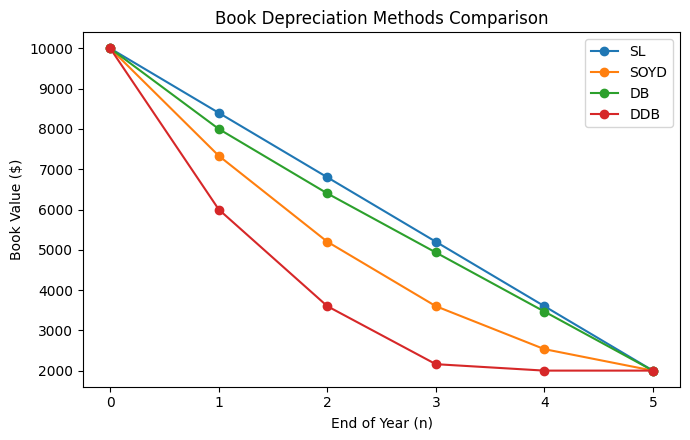

In [2]:
P, S, N = 10000, 2000, 5
methods = {
    "SL": straight_line(P, S, N),
    "SOYD": sum_of_years_digits(P, S, N),
    "DB": declining_balance(P, S, N),
    "DDB": double_declining_balance(P, S, N),
}

df_bv = pd.DataFrame({name: [P] + [row["BV_end"] for row in sched] for name, sched in methods.items()},
                      index=range(0, N + 1))
df_bv.index.name = "End of Year (n)"
display(df_bv.round(1))

plt.figure(figsize=(7, 4.5))
for name in methods:
    plt.plot(df_bv.index, df_bv[name], marker="o", label=name)
plt.xlabel("End of Year (n)"); plt.ylabel("Book Value ($)")
plt.title("Book Depreciation Methods Comparison"); plt.legend()
plt.tight_layout(); plt.show()

## 2. MACRS + Taxation (Lecture 9)

$200,000 asset, 5-year MACRS, $500k/yr revenue, $150k/yr expenses,
34% tax rate -- the full after-tax cash flow build-up.

,MACRS Rate,Depreciation,Taxable Income,Income Tax,After-Tax Income,ATCF
EOY,,,,,,
1,0.0,40000.0,310000.0,105400.0,204600.0,244600.0
2,0.0,64000.0,286000.0,97240.0,188760.0,252760.0
3,0.0,38400.0,311600.0,105944.0,205656.0,244056.0
4,0.0,23040.0,326960.0,111166.0,215794.0,238834.0
5,0.0,23040.0,326960.0,111166.0,215794.0,238834.0
6,0.0,11520.0,338480.0,115083.0,223397.0,234917.0


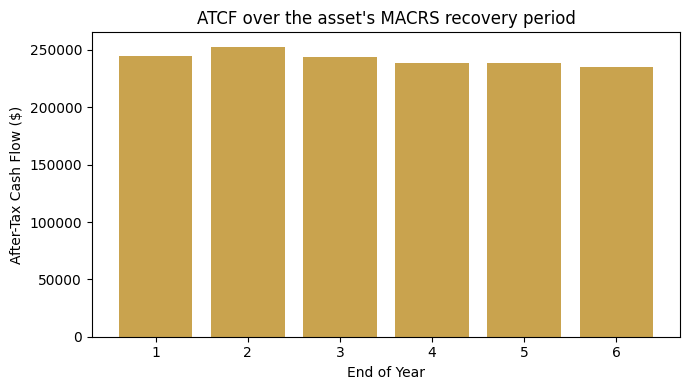

In [3]:
schedule = macrs_schedule(200000, recovery_period=5)
rows = []
for row in schedule:
    atcf = after_tax_cash_flow(revenue=500000, expenses=150000, depreciation=row["D"], tax_rate=0.34)
    rows.append({"EOY": row["n"], "MACRS Rate": row["rate"], "Depreciation": row["D"],
                 "Taxable Income": atcf["taxable_income"], "Income Tax": atcf["income_tax"],
                 "After-Tax Income": atcf["after_tax_income"], "ATCF": atcf["atcf"]})
df_macrs = pd.DataFrame(rows).set_index("EOY")
display(df_macrs.round(0))

plt.figure(figsize=(7, 4))
plt.bar(df_macrs.index, df_macrs["ATCF"], color="#c9a34e")
plt.xlabel("End of Year"); plt.ylabel("After-Tax Cash Flow ($)")
plt.title("ATCF over the asset's MACRS recovery period")
plt.tight_layout(); plt.show()

## 3. Replacement Analysis -- Economic Service Life (Lecture 10)

The forklift-truck example: which N minimizes EUAC = Capital Recovery +
Annual Equivalent Operating Cost?

,EUAC
N,
1,14700.0
2,12328.0
3,11899.0
4,12165.0
5,13632.0
6,14677.0
7,16158.0



Economic Service Life = 3 years (min EUAC = $11,899)


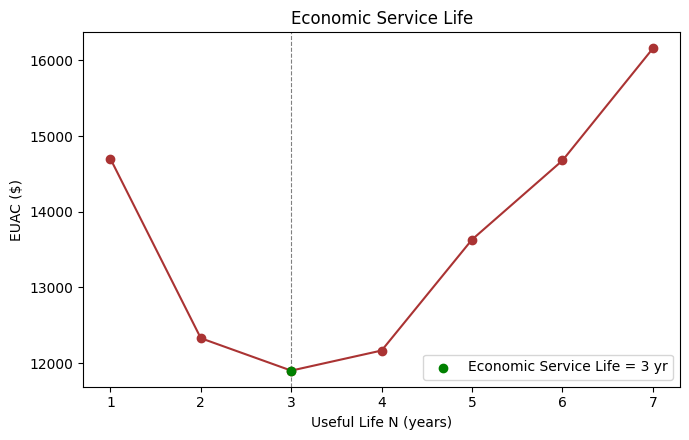

In [4]:
P, i = 18000, 0.15
OC = [4000, 5600, 7840, 10976, 15366 + 5000, 21513, 30118]
S = [10000, 7500, 5625, 4219, 3164, 2373, 1780]

result = economic_service_life(P, S, OC, i)
df_esl = pd.DataFrame({"N": list(result["euac_by_n"].keys()), "EUAC": list(result["euac_by_n"].values())})
df_esl = df_esl.set_index("N")
display(df_esl.round(0))

print(f"\nEconomic Service Life = {result['economic_service_life']} years "
      f"(min EUAC = ${result['min_euac']:,.0f})")

plt.figure(figsize=(7, 4.5))
plt.plot(df_esl.index, df_esl["EUAC"], marker="o", color="#a33")
plt.axvline(result["economic_service_life"], color="gray", linestyle="--", linewidth=0.8)
plt.scatter([result["economic_service_life"]], [result["min_euac"]], color="green", zorder=5,
            label=f"Economic Service Life = {result['economic_service_life']} yr")
plt.xlabel("Useful Life N (years)"); plt.ylabel("EUAC ($)")
plt.title("Economic Service Life"); plt.legend()
plt.tight_layout(); plt.show()

## 4. Benefit-Cost Analysis -- power plant design selection (Lecture 11)

Four competing designs; Z is pre-excluded (its own BCR < 1). Incremental
BCR selects among the rest.

In [5]:
alternatives = [
    {"name": "W", "cost": 18556, "benefit": 24822.2},
    {"name": "X", "cost": 16812, "benefit": 24216.8},
    {"name": "Y", "cost": 13953, "benefit": 20342.1},
]

df_alts = pd.DataFrame(alternatives).set_index("name")
df_alts["Own BCR"] = df_alts["benefit"] / df_alts["cost"]
display(df_alts.round(2))

result = incremental_bcr_selection(alternatives)
df_steps = pd.DataFrame(result["steps"])
display(df_steps.round(3))

print(f"\nSelected design: {result['selected']}")

,cost,benefit,Own BCR
name,,,
W,18556,24822.2,1.34
X,16812,24216.8,1.44
Y,13953,20342.1,1.46


,from,to,delta_cost,delta_benefit,incremental_bcr,decision
0,Y,X,2859,3874.7,1.355,select_to
1,X,W,1744,605.4,0.347,keep_from



Selected design: X


## Summary

All four analyses (book depreciation, MACRS/taxation, replacement
analysis, benefit-cost analysis) reproduce Dr. Alsharqawi's own worked
answers from `dgs.depreciation`, `dgs.macrs_taxation`,
`dgs.replacement_analysis`, and `dgs.benefit_cost_analysis` -- 45 tests
across the four modules, all passing.